note: this notebook is imported from google collab, and therefore file paths are not consistent with this repository structure

In [6]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/finance_assignment


Mounted at /content/drive/
/content/drive/MyDrive/finance_assignment


In [7]:
import os
import math
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [ ]:
def prepare_asx200_sentiment_data():
    """Load and aggregate the ASX200 sentiment data."""
    asx200_tickers = ['CBA', 'BHP', 'CSL', 'WBC', 'ANZ', 'FMG', 'NAB', 'MQG', 'GMG', 'WOW', 'WES', 'TLS',
                      'RIO', 'WDS', 'TCL', 'SQ2', 'ALL', 'COL', 'SCG', 'S32', 'NCM', 'SUN', 'QBE', 'BXB',
                      'FPH', 'COH', 'ASX', 'STO', 'RHC', 'AMC', 'ORG', 'IAG', 'SHL', 'DXS', 'BSL', 'APA',
                      'TWE', 'REA', 'AIA', 'DMP', 'CPU', 'TAH', 'VCX', 'MGR', 'QAN', 'GPT', 'EVN', 'SGP',
                      'BLD', 'MPL', 'JHX', 'LLC', 'SOL', 'ALD', 'WOR', 'AZJ', 'CHC', 'ORI', 'HVN', 'XRO',
                      'SVW', 'SEK', 'TPG', 'MFG', 'IEL', 'FBU', 'ALQ', 'ALX', 'NST', 'BEN', 'WTC', 'BOQ',
                      'RMD', 'IGO', 'CWY', 'AGL', 'ANN', 'CAR', 'AWC', 'VEA', 'IPL', 'WHC', 'QUB', 'A2M',
                      'APE', 'SGR', 'LNK', 'DOW', 'BRG', 'AMP', 'ORA', 'CGF', 'ALU', 'RWC', 'ARB', 'CIA',
                      'OZL', 'ILU', 'FLT', 'BKW', 'BPT', 'GOZ', 'CTD', 'CLW', 'VUK', 'CSR', 'NEC', 'DHG',
                      'MIN', 'BWP', 'BAP', 'PDL', 'RRL', 'HLS', 'IFL', 'PME', 'NHF', 'PMV', 'ABP', 'JBH',
                      'SDF', 'MTS', 'CMW', 'SBM', 'TNE', 'SGM', 'DRR', 'SCP', 'CQR', 'CNU', 'NXT', 'JHG',
                      'WEB', 'ABC', 'IRE', 'CCP', 'NUF', 'CIP', 'NWL', 'INA', 'PPT', 'HUB', 'BGA', 'WPR',
                      'ELD', 'IVC', 'AUB', 'CKF', 'IPH', 'SUL', 'CUV', 'ING', 'SLR', 'CGC', 'BKL', 'PLS',
                      'GOR', 'NAN', 'EML', 'GNC', 'NSR', 'LYC', 'GUD', 'NWS', 'KLS', 'AKE', 'ARF', 'AVZ',
                      'BRN', 'CNI', 'CHN', 'CCX', 'CXO', 'CRN', 'DEG', 'EDV', 'EVT', 'HMC', 'HDN', 'IMU',
                      'LKE', 'LIC', 'LTR', 'MP1', 'NHC', 'NIC', 'NVX', 'PDN', 'PRU', 'PNI', 'PBH', 'RMS',
                      'REH', 'SFR', 'TLX', 'TLC', 'TYR', 'UMG', 'UWL', 'ZIP']
    asx200_tickers = [f'ASX:{ticker}' for ticker in asx200_tickers]

    sentiment_data = pd.read_csv('data/sentiment_data.csv', converters={'stock_codes': ast.literal_eval})
    sentiment_data['datetime'] = pd.to_datetime(sentiment_data['date_string'])

    # Mark articles related to ASX200 and general news
    sentiment_data['is_in_asx200'] = sentiment_data['stock_codes'].apply(lambda codes: any(code in asx200_tickers for code in codes))
    sentiment_data['is_general_news'] = sentiment_data['stock_codes'].apply(lambda codes: len(codes) == 0)

    sentiment_data['bert_sentiment_label'] = sentiment_data['bert_sentiment_label'].replace({
        'Negative': -2,
        'Neutral': 0,
        'Positive': 2
    })

    sentiment_columns = ['vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound',
                         'bert_sentiment_label', 'bert_sentiment_score']
    daily_sentiment = sentiment_data.groupby('datetime')[sentiment_columns + ['stock_codes']].agg(
        article_count=('stock_codes', 'count'),
        vader_negative=('vader_negative', 'mean'),
        vader_neutral=('vader_neutral', 'mean'),
        vader_positive=('vader_positive', 'mean'),
        vader_compound=('vader_compound', 'mean'),
        bert_sentiment_label=('bert_sentiment_label', 'mean'),
        bert_sentiment_score=('bert_sentiment_score', 'mean')
    ).reset_index()
    daily_sentiment.set_index('datetime', inplace=True)
    return daily_sentiment

def plot_article_count(daily_sentiment):
    """Plot the number of articles over time."""
    plt.figure(figsize=(10, 6))
    plt.plot(daily_sentiment.index, daily_sentiment['article_count'], marker='o', linestyle='-')
    plt.xlabel('Date')
    plt.ylabel('Article Count')
    plt.title('ASX200 Daily Article Count')
    plt.xticks(rotation=45)
    plt.savefig('results/asx200_article_count.pdf', format='pdf')
    plt.show()

def get_asx200_price_data(start_date, end_date):
    """Download ASX200 index price data using yfinance."""
    price_data = yf.download('^AXJO', start=start_date, end=end_date, period='1d', group_by='ticker', threads=True)['^AXJO'].copy()
    return price_data

def merge_asx200_data(price_data, daily_sentiment):
    """Merge ASX200 price data with aggregated sentiment data."""
    merged_df = pd.merge(price_data, daily_sentiment, left_index=True, right_index=True, how='left').fillna(0)
    return merged_df

def prepare_data(merged_df, control_columns, sentiment_columns):
    """Create dataset variants for analysis."""
    data = {}
    data['Control'] = merged_df[control_columns].copy()
    for key, cols in sentiment_columns.items():
        data[key] = merged_df[control_columns + cols].copy()
    return data

def create_dataset(dataset, lookback, forecast):
    """Create lookback dataset for time-series prediction."""
    X, Y = [], []
    max_index = len(dataset) - lookback - forecast
    for i in range(max_index):
        X.append(dataset.iloc[i:i+lookback].values)
        Y.append(dataset['Close'].iloc[i + lookback + forecast - 1])
    return np.array(X), np.array(Y)

def train_test_split_data(data_df, train_proportion, lookback, forecast):
    """Split the data into train/test, scale it, and create lookback datasets."""
    train_size = int(len(data_df) * train_proportion)
    train_data = data_df.iloc[:train_size].copy()
    test_data = data_df.iloc[train_size:].copy()

    scaler = MinMaxScaler()
    scaler.fit(train_data)
    train_scaled = pd.DataFrame(scaler.transform(train_data), columns=train_data.columns, index=train_data.index)
    test_scaled = pd.DataFrame(scaler.transform(test_data), columns=test_data.columns, index=test_data.index)

    X_train, Y_train = create_dataset(train_scaled, lookback, forecast)
    X_test, Y_test = create_dataset(test_scaled, lookback, forecast)

    # Ensure the shape is [samples, timesteps, features]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2])
    return X_train, Y_train, X_test, Y_test, scaler

def create_lstm_model(input_shape):
    """Create and compile an LSTM model."""
    optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
    model = Sequential()
    model.add(LSTM(64, activation="tanh", return_sequences=True, input_shape=input_shape))
    model.add(LSTM(32, activation="tanh"))
    model.add(Dense(1, activation='linear'))
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    return model

def build_and_train_model(X_train, Y_train, input_shape, max_epochs, patience):
    """Build and train the SimpleRNN model with early stopping."""
    model = create_lstm_model(input_shape)
    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    history = model.fit(X_train, Y_train, epochs=max_epochs, batch_size=64,
                        validation_split=0.3, callbacks=[early_stop], verbose=1)
    return model, history

def make_predictions(model, X, Y_true):
    """Make predictions using the trained model."""
    Y_pred = model.predict(X).reshape(-1)
    return Y_true, Y_pred

def calculate_metrics(y_true, y_pred):
    """Calculate MSE, RMSE, and MAE."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, mae

def plot_training_loss(loss_dict, stock_name, output_dir):
    """Plot the training loss vs epochs for each model variant."""
    plt.figure(figsize=(10, 6))
    plt.semilogy(loss_dict.get('Control', []), label='Control Model', linewidth=2, color='black')
    plt.semilogy(loss_dict.get('Vader', []), label='Vader Model', linewidth=2, color='red')
    plt.semilogy(loss_dict.get('BERT', []), label='Bert Model', linewidth=2, color='blue')
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)
    plt.gca().yaxis.set_minor_formatter(plt.NullFormatter())
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss of Different RNN Models')
    plt.legend()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'{stock_name}_model_training_loss.pdf'), format='pdf')
    plt.show()

def plot_test_results(test_dates, actual, predictions, stock_name, output_dir):
    """Create a 3-panel subplot of actual vs predicted, residuals over time, and residual KDE."""
    # Compute residuals for each model
    residuals = {}
    for key, pred in predictions.items():
        residuals[key] = actual - pred

    # Prepare DataFrame for KDE plotting of residuals
    residuals_df = pd.DataFrame(residuals)
    melted_res = residuals_df.melt(var_name='Model', value_name='Residuals')
    model_colours = {'Control': 'blue', 'Vader': 'green', 'BERT': 'red'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax1 = axes[0]
    ax1.plot(test_dates, actual, label='Actual Price', color='black')
    ax1.plot(test_dates, predictions.get('Control', []), label='Control Model', color='blue')
    ax1.plot(test_dates, predictions.get('Vader', []), label='Vader Model', color='green')
    ax1.plot(test_dates, predictions.get('BERT', []), label='BERT Model', color='red')
    ax1.set_title(f'{stock_name} - Test Data - Actual vs Predicted')
    ax1.set_ylabel('Stock Price')
    ax1.grid(True)
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    ax2 = axes[1]
    ax2.axhline(0, color='black', linestyle='-', label='Ideal Residual')
    ax2.plot(test_dates, residuals.get('Control', []), label='Residual Control', color='blue')
    ax2.plot(test_dates, residuals.get('Vader', []), label='Residual Vader', color='green')
    ax2.plot(test_dates, residuals.get('BERT', []), label='Residual BERT', color='red')
    ax2.set_title(f'{stock_name} - Test Data - Residuals Over Time')
    ax2.set_ylabel('Residual (Actual - Predicted)')
    ax2.grid(True)
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    ax3 = axes[2]
    sns.kdeplot(
        data=melted_res,
        x='Residuals',
        hue='Model',
        fill=True,
        alpha=0.1,
        palette=model_colours,
        ax=ax3
    )
    for model, color in model_colours.items():
        mean_res = residuals_df[model].mean()
        ax3.axvline(mean_res, color=color, linestyle='--', label=f'{model} (Mean: {mean_res:.4f})')
    ax3.set_title(f'{stock_name} - Test Data - Residual Distribution')
    ax3.set_xlabel('Residuals')
    ax3.set_ylabel('Density')
    ax3.grid(True)
    ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=11)

    plt.tight_layout()
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.savefig(os.path.join(output_dir, f'residuals_{stock_name}.pdf'), format='pdf')
    plt.show()

def train_and_evaluate_asx200(max_epochs=250, patience=25, train_proportion=0.7, lookback=30, forecast=1,
                              control_columns=['Close'],
                              sentiment_columns={'Vader': ['vader_negative', 'vader_neutral', 'vader_positive', 'vader_compound'],
                                                 'BERT': ['bert_sentiment_score', 'bert_sentiment_label']},
                              output_dir='results'):
    """Run the full analysis pipeline for the ASX200 index using preprocessed sentiment data."""
    # prepare sentiment data and plot article cont over time
    daily_sentiment = prepare_asx200_sentiment_data()
    plot_article_count(daily_sentiment)

    # determine the date range from sentiment data
    start_date = daily_sentiment.index.min().strftime('%Y-%m-%d')
    end_date = daily_sentiment.index.max().strftime('%Y-%m-%d')

    # get ASX200 index price data via yfinance
    price_data = get_asx200_price_data(start_date, end_date)

    # Merge price data with daily sentiment data
    merged_df = merge_asx200_data(price_data, daily_sentiment)

    # prepare dataset variants (Control, Vader, and BERT)
    data_variants = prepare_data(merged_df, control_columns, sentiment_columns)

    performance = []
    loss_dict = {}
    pred_dict = {}
    control_Y_true = None
    test_dates = None

    # For each variant, split the data, train the model, and record predictions/metrics
    for key, dataset in data_variants.items():
        X_train, Y_train, X_test, Y_test, scaler = train_test_split_data(dataset, train_proportion, lookback, forecast)
        input_shape = (X_train.shape[1], X_train.shape[2])
        model, history = build_and_train_model(X_train, Y_train, input_shape, max_epochs, patience)
        loss_dict[key] = history.history['loss']

        Y_true, Y_pred = make_predictions(model, X_test, Y_test)
        # For the control variant  record the test dates and actual values for plotting
        if key == 'Control':
            train_size = int(len(dataset) * train_proportion)
            test_data = dataset.iloc[train_size:]
            test_dates = test_data.index[lookback + forecast - 1:][:len(Y_test)]
            control_Y_true = Y_true

        mse, rmse, mae = calculate_metrics(Y_true, Y_pred)
        performance.append({'Model': key + '_ASX200', 'MSE': mse, 'RMSE': rmse, 'MAE': mae})
        pred_dict[key] = Y_pred

    # plot the training loss and test results using the custom formatting
    plot_training_loss(loss_dict, 'ASX200', output_dir)
    plot_test_results(test_dates, control_Y_true, pred_dict, 'ASX200', output_dir)

    return pd.DataFrame(performance)


<ipython-input-4-02be61362ea9>:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sentiment_data['bert_sentiment_label'] = sentiment_data['bert_sentiment_label'].replace({


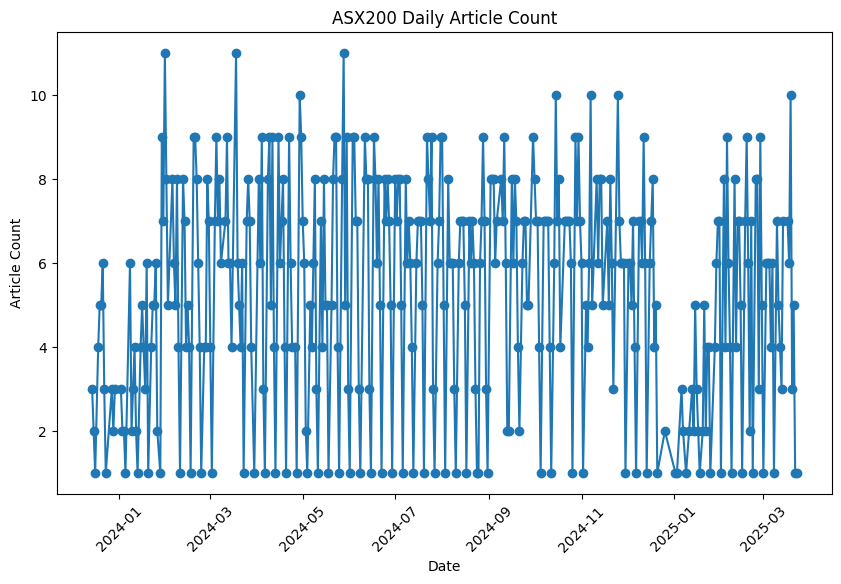

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - loss: 0.3497 - val_loss: 0.4816
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1836 - val_loss: 0.1149
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0782 - val_loss: 0.0859
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1175 - val_loss: 0.0884
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0699 - val_loss: 0.2091
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0792 - val_loss: 0.2208
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0821 - val_loss: 0.1650
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0674 - val_loss: 0.1056
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0667 - val_loss: 0.1037
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0686 - val_loss: 0.1371
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0636 - val_loss: 0.1587
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0642 - val_loss: 0.1506


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 421ms/step - loss: 0.3961 - val_loss: 0.4727
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1157 - val_loss: 0.2052
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1535 - val_loss: 0.3086
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0993 - val_loss: 0.4394
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1074 - val_loss: 0.4624
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.1080 - val_loss: 0.4039
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0946 - val_loss: 0.3257
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0962 - val_loss: 0.3084
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0938 - val_loss: 0.3342
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0856 - val_loss: 0.3606
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0878 - val_loss: 0.3517
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0847 - val_loss: 0.2963
Epoch 13/50

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - loss: 0.2847 - val_loss: 0.3794
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1095 - val_loss: 0.1843
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1399 - val_loss: 0.2783
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0881 - val_loss: 0.3775
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1000 - val_loss: 0.3830
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0950 - val_loss: 0.3168
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0842 - val_loss: 0.2344
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0836 - val_loss: 0.2101
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0807 - val_loss: 0.2331
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0740 - val_loss: 0.2479
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0751 - val_loss: 0.2190
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0688 - val_loss: 0.1461
Epoch 13/50

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step


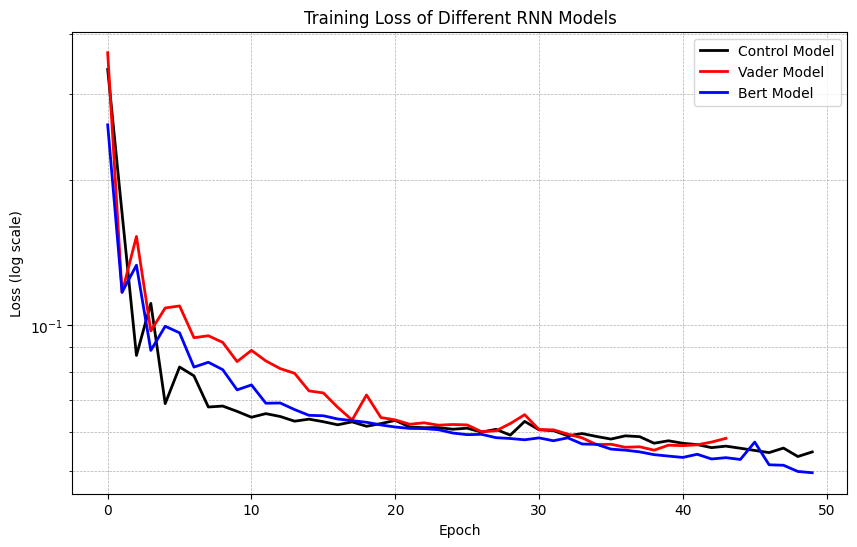

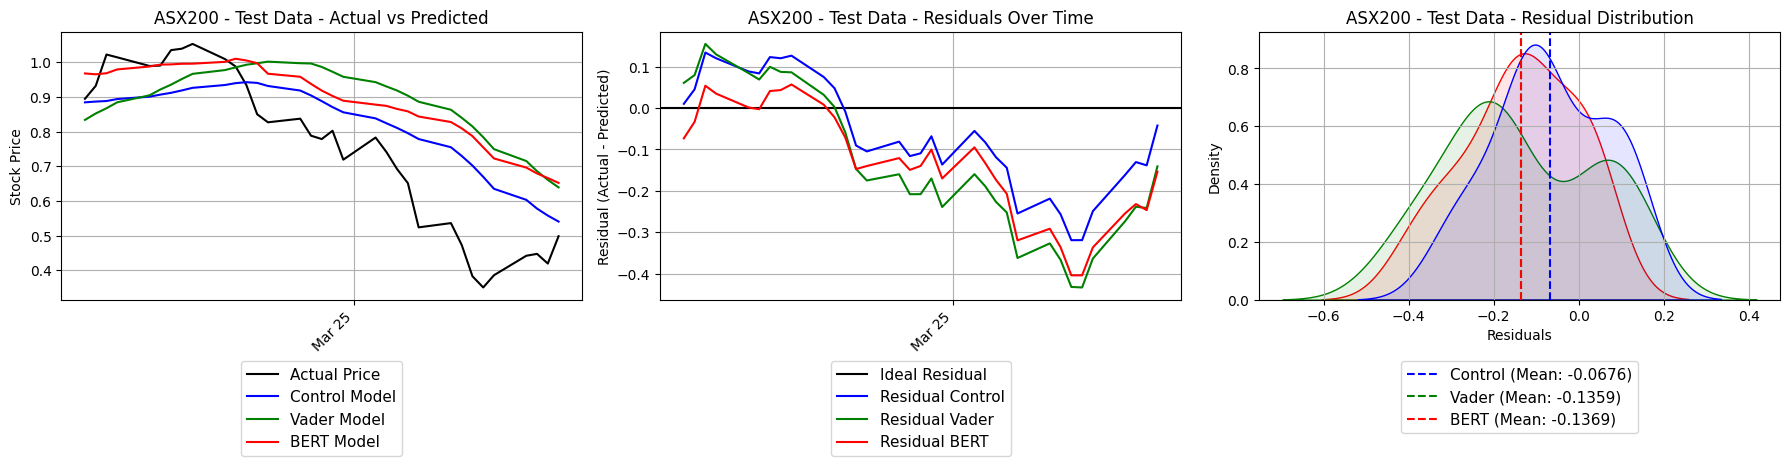

,Model,MSE,RMSE,MAE
0,Control_ASX200,0.022140,0.148794,0.126688
1,Vader_ASX200,0.048714,0.220713,0.189641
2,BERT_ASX200,0.036432,0.190871,0.151437


In [ ]:
performance_df = train_and_evaluate_asx200(max_epochs=50, train_proportion=0.7)  # Use fewer epochs for testing
performance_df